In [1]:
#%pip install flavio wilson iminuit matplotlib numpy scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from iminuit import Minuit
import flavio
from flavio.statistics.likelihood import FastLikelihood
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

observables = [
    # Muy limpios y centrales
    'BR(Bs->mumu)',
    'BR(B0->mumu)',  # para evitar inconsistencia: algunas measurements constriñen ambos a la vez

    # LFU ratios (R_K y R_K* en bins típicos)
    ('<Rmue>(B+->Kll)', 1.1, 6.0),         # ~ R_K
    ('<Rmue>(B0->K*ll)', 0.045, 1.1),      # ~ R_K* low-q2
    ('<Rmue>(B0->K*ll)', 1.1, 6.0),        # ~ R_K* central-q2

    # Angular observable (P5') en región q2 donde QCDF es "más razonable"
    ('<P5p>(B0->K*mumu)', 4.0, 6.0),

    # Differential BR examples (en región baja q2)
    ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0),
    ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0),
]

In [3]:
# Centramos los parámetros del SM para el cálculo de la log-likelihood
par_central = flavio.default_parameters.get_central_all()

# Usamos FastLikelihood para crear la función de log-verosimilitud con los observables y parámetros definidos
fl = FastLikelihood('rareB_baseline', observables=observables, nuisance_parameters='all')

# Hacemos un test rápido para asegurarnos de que todo funciona y no hay errores de configuración
fl.make_measurement(N=3000, Nexp=3000, threads=1)

# Log-likelihood en el SM (WCs NP = 0)
wc_sm = flavio.WilsonCoefficients()    # SM => NP contribuciones = 0
ll_sm = fl.log_likelihood(par_central, wc_sm)
ll_sm

np.float64(55.70039476347107)

In [4]:
# 1. Función de likelihood para 4 parámetros
def loglike_4D(C9, C10, C9p, C10p, scale=5.0):
    wc = flavio.WilsonCoefficients()
    # Inyectamos NP en los 4 coeficientes
    wc_dict = {
        'C9_bsmumu': C9, 
        'C10_bsmumu': C10,
        'C9p_bsmumu': C9p,   # C9 prime
        'C10p_bsmumu': C10p  # C10 prime
    }
    wc.set_initial(wc_dict, scale)
    return fl.log_likelihood(par_central, wc)

# 2. Envoltorio para MINUIT
def nll(C9, C10, C9p, C10p):
    return -loglike_4D(C9, C10, C9p, C10p)

# 3. Inicializamos Minuit con 4 parámetros en el SM (0.0)
m = Minuit(nll, C9=0.0, C10=0.0, C9p=0.0, C10p=0.0)
m.errordef = 0.5  # NLL = -logL

# 4. Minimización y cálculo de errores
m.migrad()
m.hesse()
m.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -79.86                     │              Nfcn = 783              │
│ EDM = 2.62e-05 (Goal: 0.0001)    │           time = 852.3 sec           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ C9   │   -1.6    │    0.4    │    -0.4    │    0.5     │         │         │       │
│ 1 │ C10  │   -0.28   │   0.12    │   -0.10    │    0.16    │         │         │       │
│ 2 │ C9p  │   -0.7    │    0.4    │    -0.4    │    0.4     │         │         │       │
│ 3 │ C10p │   -0.60   │   0.15    │   -0.12    │    0.18    │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          C9           │          C10          │          C9p          │         C10p          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.4    │    0.5    │   -0.10   │   0.16    │   -0.4    │    0.4    │   -0.12   │   0.18    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌──────┬─────────────────────────────┐
│      │     C9    C10    C9p   C10p │
├──────┼─────────────────────────────┤
│   C9 │  0.191  0.045   0.11  0.049 │
│  C10 │  0.045 0.0154  0.036  0.013 │
│  C9p │   0.11  0.036  0.177  0.051 │
│ C10p │  0.049  0.013  0.051 0.0212 │
└──────┴─────────────────────────────┘

In [5]:
print("\n=== Best-fit parameters (4D) ===")
for p in m.params:
    print(f"{p.name:6s} = {p.value:+.6f} ± {p.error:.6f}")


=== Best-fit parameters (4D) ===
C9     = -1.612630 ± 0.436779
C10    = -0.280980 ± 0.124156
C9p    = -0.657244 ± 0.420922
C10p   = -0.596563 ± 0.145448


In [6]:
# Extraemos el likelihood del mejor ajuste en 4D
ll_best = -m.fval

# Calculamos el Delta chi^2 respecto al SM (ll_sm calculado en el Paso 2)
delta_chi2_sm = -2 * (ll_sm - ll_best)

# --- Grados de libertad en 4D ---
gl = 4  

# Cálculo del p-value y el pull
p_value = stats.chi2.sf(delta_chi2_sm, df=gl)
pull_exacto = stats.norm.isf(p_value / 2)

print("\n=== SM Pull (4D Fit) ===")
print(f"Log-Likelihood (SM): {ll_sm:.4f}")
print(f"Log-Likelihood (Best-Fit): {ll_best:.4f}")
print(f"Delta chi^2: {delta_chi2_sm:.2f}")
print(f"Grados de libertad (DOF): {gl}")
print(f"p-value del SM: {p_value:.2e}")
print(f"Pull del SM: {pull_exacto:.2f} sigmas")


=== SM Pull (4D Fit) ===
Log-Likelihood (SM): 55.7004
Log-Likelihood (Best-Fit): 79.8641
Delta chi^2: 48.33
Grados de libertad (DOF): 4
p-value del SM: 8.07e-10
Pull del SM: 6.14 sigmas


In [7]:
# 1. Definimos grupos
obs_br = ['BR(Bs->mumu)', 'BR(B0->mumu)']
obs_leptones_lfu = [('<Rmue>(B+->Kll)', 1.1, 6.0), ('<Rmue>(B0->K*ll)', 0.045, 1.1), ('<Rmue>(B0->K*ll)', 1.1, 6.0)]
obs_muones = [('<P5p>(B0->K*mumu)', 4.0, 6.0), ('<dBR/dq2>(B+->Kmumu)', 1.1, 6.0), ('<dBR/dq2>(Bs->phimumu)', 1.1, 6.0)]

print("Inicializando FastLikelihoods por grupos...")
fl_br = FastLikelihood('rareB_br', observables=obs_br, nuisance_parameters='all')
fl_br.make_measurement(N=3000, Nexp=3000, threads=1)

fl_lfu = FastLikelihood('rareB_lfu', observables=obs_leptones_lfu, nuisance_parameters='all')
fl_lfu.make_measurement(N=3000, Nexp=3000, threads=1)

fl_muon = FastLikelihood('rareB_muon', observables=obs_muones, nuisance_parameters='all')
fl_muon.make_measurement(N=3000, Nexp=3000, threads=1)

# Extraemos los mejores ajustes del 4D global
bf = {
    'C9_bsmumu': m.values['C9'],
    'C10_bsmumu': m.values['C10'],
    'C9p_bsmumu': m.values['C9p'],
    'C10p_bsmumu': m.values['C10p']
}

print("Calculando máximos reales (4D) para BR, LFU y Muones...")
par_central = flavio.default_parameters.get_central_all()

# Funciones auxiliares para minimizar en el espacio 4D
def get_max_ll_4D(fl_obj):
    def nll_4d(C9, C10, C9p, C10p):
        wc = flavio.WilsonCoefficients()
        wc.set_initial({'C9_bsmumu': C9, 'C10_bsmumu': C10, 'C9p_bsmumu': C9p, 'C10p_bsmumu': C10p}, 5.0)
        return -fl_obj.log_likelihood(par_central, wc)
    
    m_temp = Minuit(nll_4d, C9=0.0, C10=0.0, C9p=0.0, C10p=0.0)
    m_temp.errordef = 0.5
    m_temp.migrad()
    return -m_temp.fval

ll_max_br_4d = get_max_ll_4D(fl_br)
ll_max_lfu_4d = get_max_ll_4D(fl_lfu)
ll_max_muon_4d = get_max_ll_4D(fl_muon)
ll_max_tot_4d = -m.fval

# Función pura de cálculo (sin gráficos) - AHORA USA LOS MÁXIMOS REALES
def compute_4D_slice(param_x, param_y, x_limits, y_limits, n_points=50):
    print(f"Calculando grid para: {param_x} vs {param_y}...")
    
    grid_x = np.linspace(x_limits[0], x_limits[1], n_points)
    grid_y = np.linspace(y_limits[0], y_limits[1], n_points)
    
    Z_tot  = np.empty((n_points, n_points))
    Z_br   = np.empty((n_points, n_points))
    Z_lfu  = np.empty((n_points, n_points))
    Z_muon = np.empty((n_points, n_points))
    
    for i, y_val in enumerate(grid_y):
        for j, x_val in enumerate(grid_x):
            wc_dict = bf.copy()
            wc_dict[param_x] = x_val
            wc_dict[param_y] = y_val
            
            wc = flavio.WilsonCoefficients()
            wc.set_initial(wc_dict, 5.0)
            
            Z_tot[i, j]  = fl.log_likelihood(par_central, wc)
            Z_br[i, j]   = fl_br.log_likelihood(par_central, wc)
            Z_lfu[i, j]  = fl_lfu.log_likelihood(par_central, wc)
            Z_muon[i, j] = fl_muon.log_likelihood(par_central, wc)

    # USAMOS LOS MÁXIMOS ABSOLUTOS EN LUGAR DE np.max()
    chi2_tot  = -2 * (Z_tot - ll_max_tot_4d)
    chi2_br   = -2 * (Z_br - ll_max_br_4d)
    chi2_lfu  = -2 * (Z_lfu - ll_max_lfu_4d)
    chi2_muon = -2 * (Z_muon - ll_max_muon_4d)
    
    return grid_x, grid_y, chi2_br, chi2_lfu, chi2_muon, chi2_tot

# Ejecutamos los escaneos
resultados_4D = {}
print("\n--- INICIANDO CÁLCULOS ---")
resultados_4D['C9_C10']   = compute_4D_slice('C9_bsmumu', 'C10_bsmumu', (-3.0, 0.5), (-1.0, 0.5))
resultados_4D['C9p_C10p'] = compute_4D_slice('C9p_bsmumu', 'C10p_bsmumu', (-2.0, 1.0), (-1.5, 0.5))
resultados_4D['C9_C9p']   = compute_4D_slice('C9_bsmumu', 'C9p_bsmumu', (-3.0, 0.5), (-2.0, 1.0))
resultados_4D['C10_C10p'] = compute_4D_slice('C10_bsmumu', 'C10p_bsmumu', (-1.0, 0.5), (-1.5, 0.5))
resultados_4D['C9_C10p']  = compute_4D_slice('C9_bsmumu', 'C10p_bsmumu', (-3.0, 0.5), (-1.5, 0.5))
resultados_4D['C10_C9p']  = compute_4D_slice('C10_bsmumu', 'C9p_bsmumu', (-1.0, 0.5), (-2.0, 1.0))
print("--- CÁLCULOS FINALIZADOS ---\n")

Inicializando FastLikelihoods por grupos...
Calculando máximos reales (4D) para BR, LFU y Muones...

--- INICIANDO CÁLCULOS ---
Calculando grid para: C9_bsmumu vs C10_bsmumu...
Calculando grid para: C9p_bsmumu vs C10p_bsmumu...
Calculando grid para: C9_bsmumu vs C9p_bsmumu...
Calculando grid para: C10_bsmumu vs C10p_bsmumu...
Calculando grid para: C9_bsmumu vs C10p_bsmumu...
Calculando grid para: C10_bsmumu vs C9p_bsmumu...
--- CÁLCULOS FINALIZADOS ---



Generando proyecciones 2D (Estilo Paper Translúcido)...


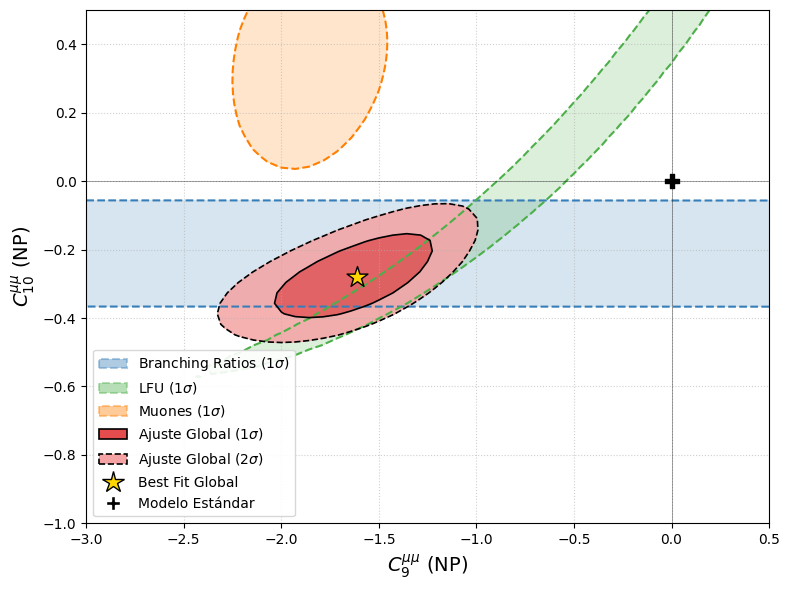

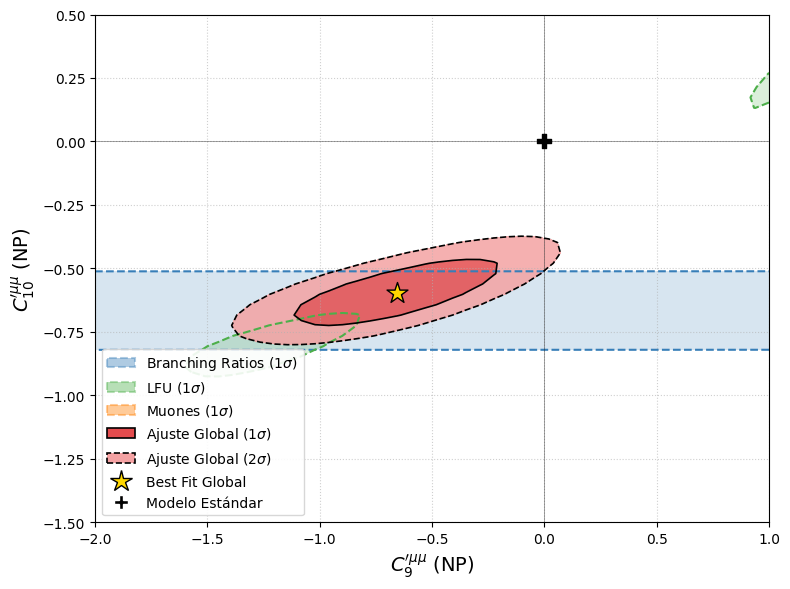

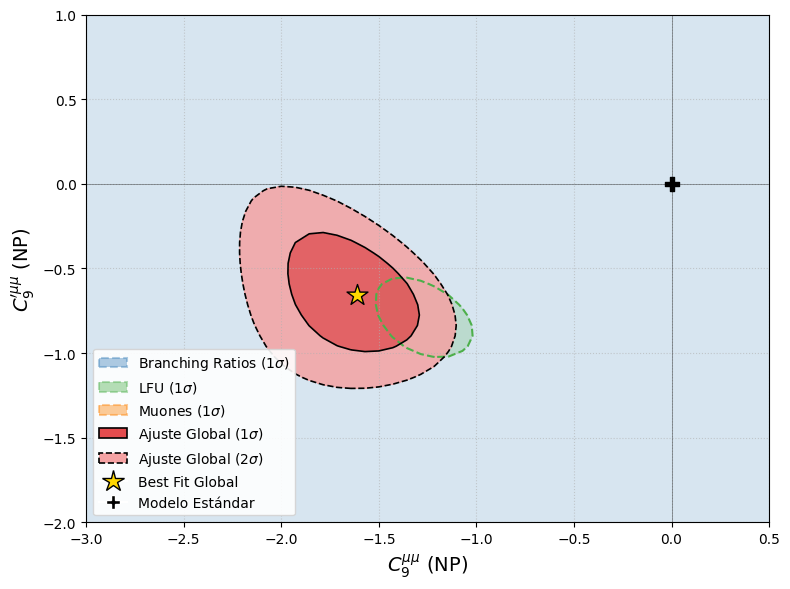

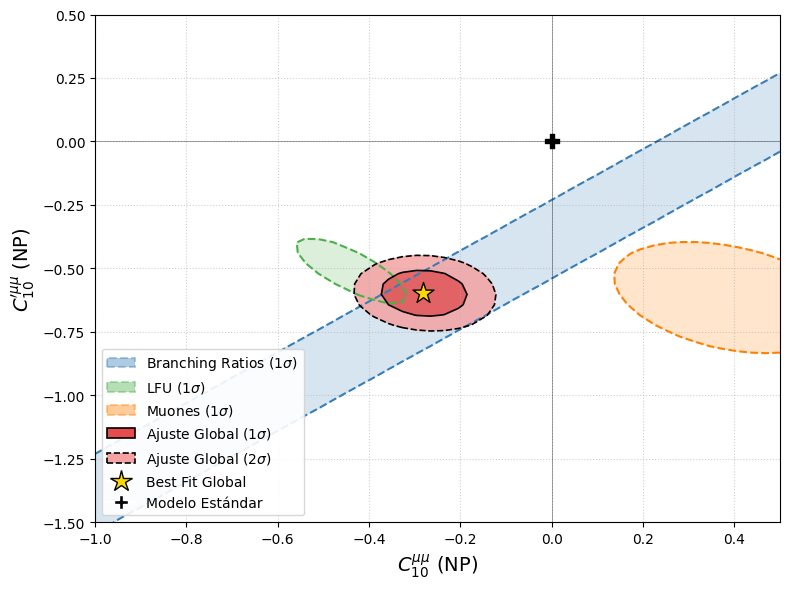

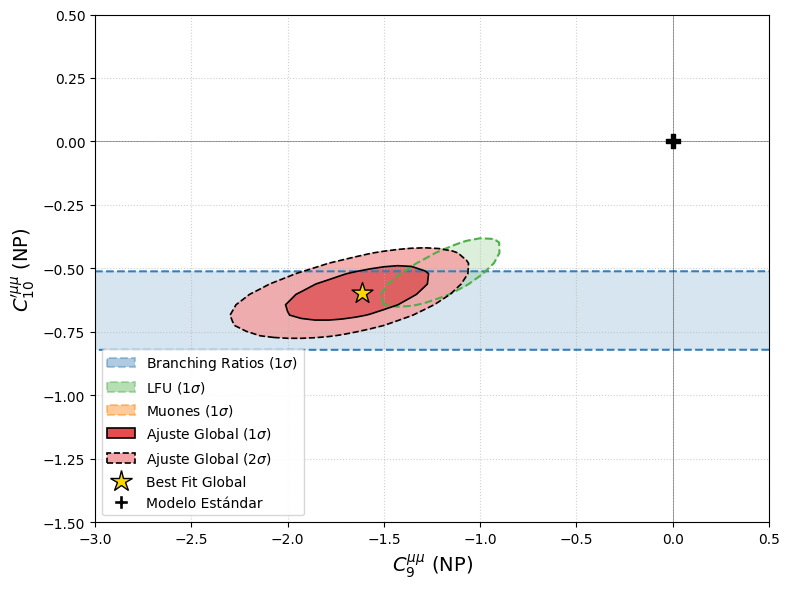

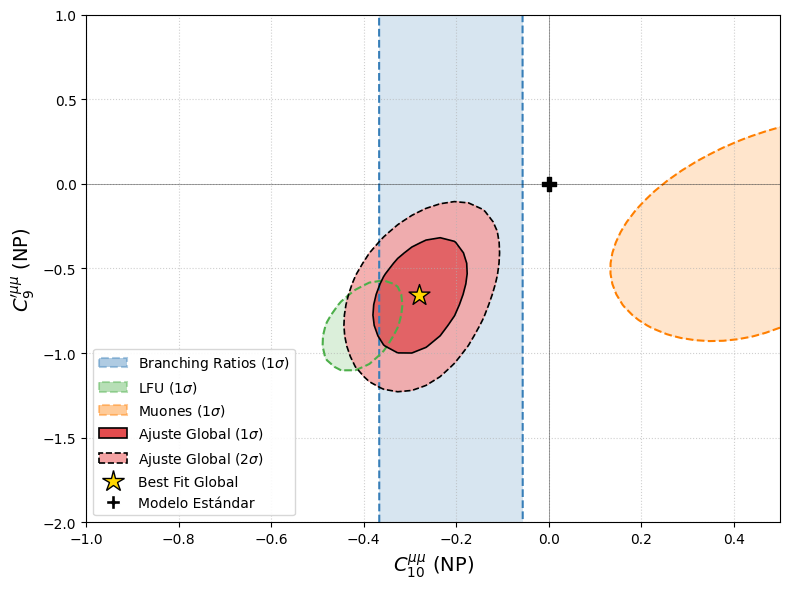

In [12]:
# --- FUNCIÓN DE DIBUJO ACTUALIZADA (Estilo Translúcido) ---
def plot_paper_style_slice(param_x, param_y, label_x, label_y, data_tuple):
    grid_x, grid_y, chi2_br, chi2_lfu, chi2_muon, chi2_tot = data_tuple
    fig, ax = plt.subplots(figsize=(8, 6))
    
    level_1sigma = [2.30]
    level_1sigma_fill = [0, 2.30]
    levels_tot = [0, 2.30, 6.18]

    # 1. OBSERVABLES INDIVIDUALES (Translúcidos de fondo)
    ax.contourf(grid_x, grid_y, chi2_br, levels=level_1sigma_fill, colors=['#377eb8'], alpha=0.2)
    ax.contourf(grid_x, grid_y, chi2_lfu, levels=level_1sigma_fill, colors=['#4daf4a'], alpha=0.2)
    ax.contourf(grid_x, grid_y, chi2_muon, levels=level_1sigma_fill, colors=['#ff7f00'], alpha=0.2)

    ax.contour(grid_x, grid_y, chi2_br, levels=level_1sigma, colors='#377eb8', linewidths=1.5, linestyles='--')
    ax.contour(grid_x, grid_y, chi2_lfu, levels=level_1sigma, colors='#4daf4a', linewidths=1.5, linestyles='--')
    ax.contour(grid_x, grid_y, chi2_muon, levels=level_1sigma, colors='#ff7f00', linewidths=1.5, linestyles='--')

    # 2. AJUSTE GLOBAL (Sólido encima)
    ax.contourf(grid_x, grid_y, chi2_tot, levels=levels_tot, colors=['#E44C4E', '#F4A2A3'], alpha=0.85)
    ax.contour(grid_x, grid_y, chi2_tot, levels=[2.30, 6.18], colors=['black', 'black'], linestyles=['-', '--'], linewidths=1.2)

    # 3. MARCADORES
    ax.scatter([bf[param_x]], [bf[param_y]], marker='*', color='gold', edgecolor='black', s=250, zorder=10)
    ax.scatter([0], [0], marker='P', color='black', s=100, zorder=10)

    # 4. LEYENDA
    legend_elements = [
        mpatches.Patch(facecolor='#377eb8', alpha=0.4, edgecolor='#377eb8', linestyle='--', linewidth=1.5, label=r'Branching Ratios ($1\sigma$)'),
        mpatches.Patch(facecolor='#4daf4a', alpha=0.4, edgecolor='#4daf4a', linestyle='--', linewidth=1.5, label=r'LFU ($1\sigma$)'),
        mpatches.Patch(facecolor='#ff7f00', alpha=0.4, edgecolor='#ff7f00', linestyle='--', linewidth=1.5, label=r'Muones ($1\sigma$)'),
        mpatches.Patch(facecolor='#E44C4E', edgecolor='black', linewidth=1.2, label=r'Ajuste Global ($1\sigma$)'),
        mpatches.Patch(facecolor='#F4A2A3', edgecolor='black', linestyle='--', linewidth=1.2, label=r'Ajuste Global ($2\sigma$)'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=16, label='Best Fit Global'),
        Line2D([0], [0], marker='P', color='w', markerfacecolor='black', markersize=10, label='Modelo Estándar')
    ]

    ax.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9, edgecolor='lightgray')

    # 5. ESTÉTICA
    ax.set_xlabel(label_x, fontsize=14)
    ax.set_ylabel(label_y, fontsize=14)
    #ax.set_title(f'Proyección 2D del Ajuste Global 4D', fontsize=15, pad=15)
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

print("Generando proyecciones 2D (Estilo Paper Translúcido)...")
plot_paper_style_slice('C9_bsmumu', 'C10_bsmumu', r'$C_9^{\mu\mu}$ (NP)', r'$C_{10}^{\mu\mu}$ (NP)', resultados_4D['C9_C10'])
plot_paper_style_slice('C9p_bsmumu', 'C10p_bsmumu', r"$C_9^{\prime \mu\mu}$ (NP)", r"$C_{10}^{\prime \mu\mu}$ (NP)", resultados_4D['C9p_C10p'])
plot_paper_style_slice('C9_bsmumu', 'C9p_bsmumu', r'$C_9^{\mu\mu}$ (NP)', r"$C_9^{\prime \mu\mu}$ (NP)", resultados_4D['C9_C9p'])
plot_paper_style_slice('C10_bsmumu', 'C10p_bsmumu', r'$C_{10}^{\mu\mu}$ (NP)', r"$C_{10}^{\prime \mu\mu}$ (NP)", resultados_4D['C10_C10p'])
plot_paper_style_slice('C9_bsmumu', 'C10p_bsmumu', r'$C_9^{\mu\mu}$ (NP)', r"$C_{10}^{\prime \mu\mu}$ (NP)", resultados_4D['C9_C10p'])
plot_paper_style_slice('C10_bsmumu', 'C9p_bsmumu', r'$C_{10}^{\mu\mu}$ (NP)', r"$C_9^{\prime \mu\mu}$ (NP)", resultados_4D['C10_C9p'])